# Previsao em Serie Temporal

Faremos uma implementação de previsao (forecasting) bem simples, utilizando uma serie temporal (time series) de consumo de energia eletrica.

Dataset utilizado: Open Power System Data ([OPSD](https://open-power-system-data.org/)).  Este dataset contem dados diarios de: consumo de energia eletrica; producao de energia eolica; producao de energia solar. De 2006 a 2017.

Vamos considerar apenas o consumo de energia eletrica.

O objetivo desta atividade não é produzir um super preditor, mas fazer um preditor simples, usando conceitos novos de regularização e compreendendo uma nova forma de preparar os dados (para um problema de natureza diferente dos vistos anterioremente).

## Imports

In [1]:
import requests
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga dos Dados

### Setup do acesso ao Drive

In [2]:
orig_url='https://drive.google.com/file/d/1fZAUBMt94Q4zEEpkgwNgcM4JbKt1gaGG/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)

#### Leitura da base e ajuste do index

In [3]:
df = pd.read_csv(csv_raw, sep=",", index_col=0)
df.index = pd.to_datetime(df.index)

In [4]:
df.head()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


## Algumas Visualizacoes

#### Histograma do consumo

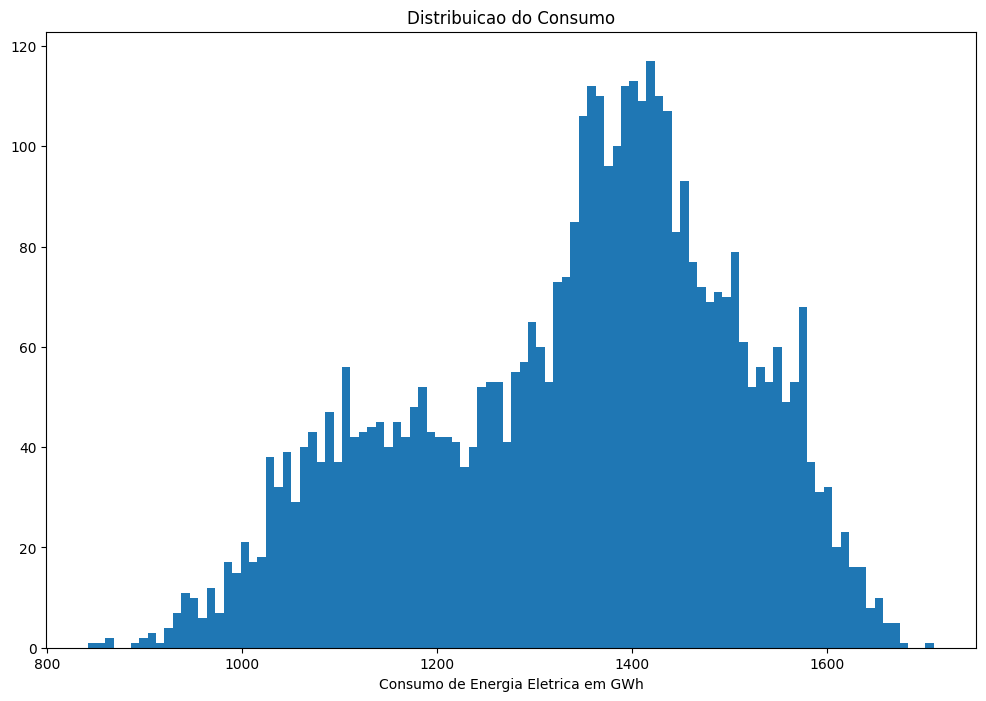

In [5]:
plt.figure(figsize=(12,8))
plt.hist(df['Consumption'], bins=100)
plt.title("Distribuicao do Consumo")
plt.xlabel("Consumo de Energia Eletrica em GWh")
plt.show()

#### Consumo ao longo do tempo

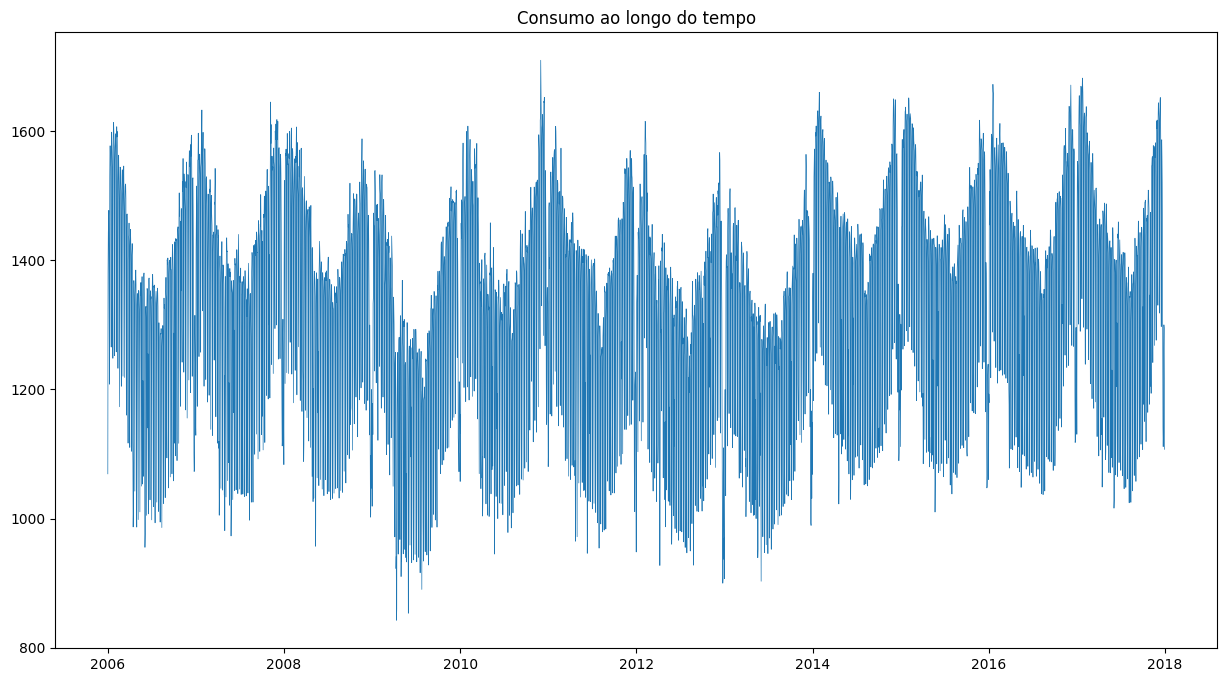

In [6]:
plt.figure(figsize=(15,8))
plt.plot(df['Consumption'], linewidth = 0.5)
plt.title("Consumo ao longo do tempo")
plt.show()

#### Consumo ao longo do tempo (outra forma)

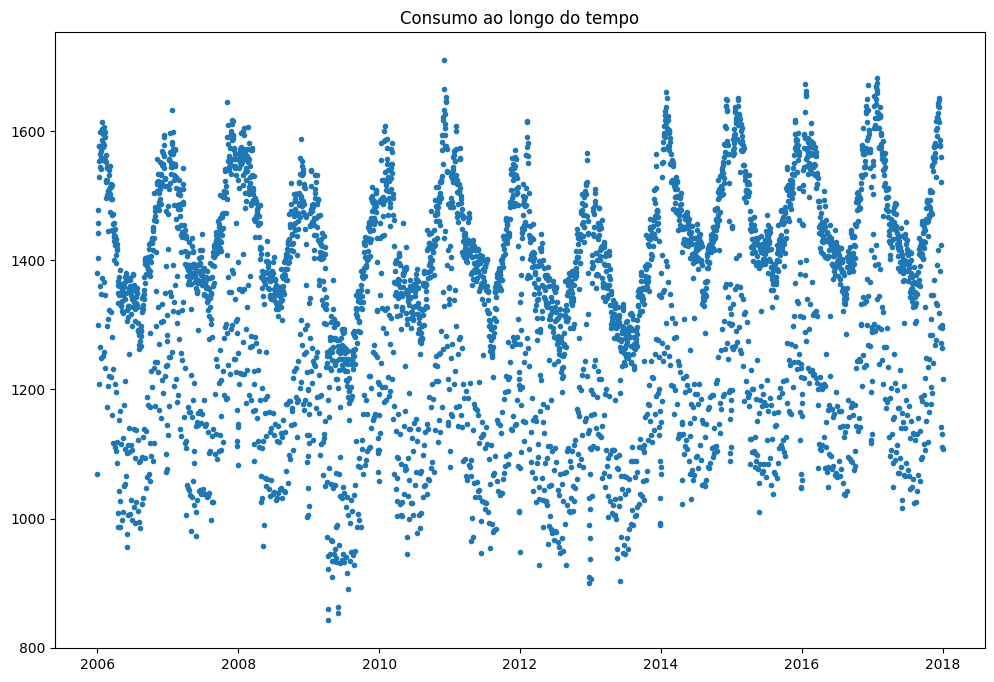

In [7]:
plt.figure(figsize=(12,8))
plt.plot(df['Consumption'], linewidth = 0.5, linestyle = "None", marker='.')
plt.title("Consumo ao longo do tempo")
plt.show()

#### Consumo ao longo do tempo (filtrando um periodo)

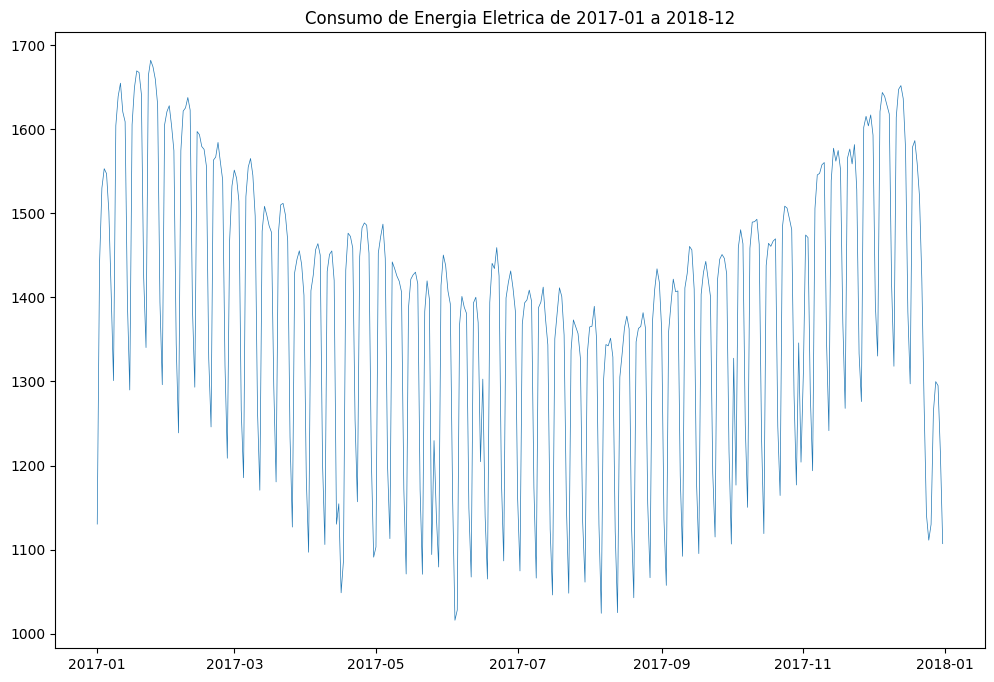

In [8]:
begin = '2017-01'
end = '2018-12'
plt.figure(figsize=(12,8))
plt.plot(df.loc[begin:end]['Consumption'], linewidth = 0.5)
plt.title("Consumo de Energia Eletrica de %s a %s" % (begin, end))
plt.show()


#### Boxplots do consumo por ano, mes, dia

In [9]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

import seaborn as sns

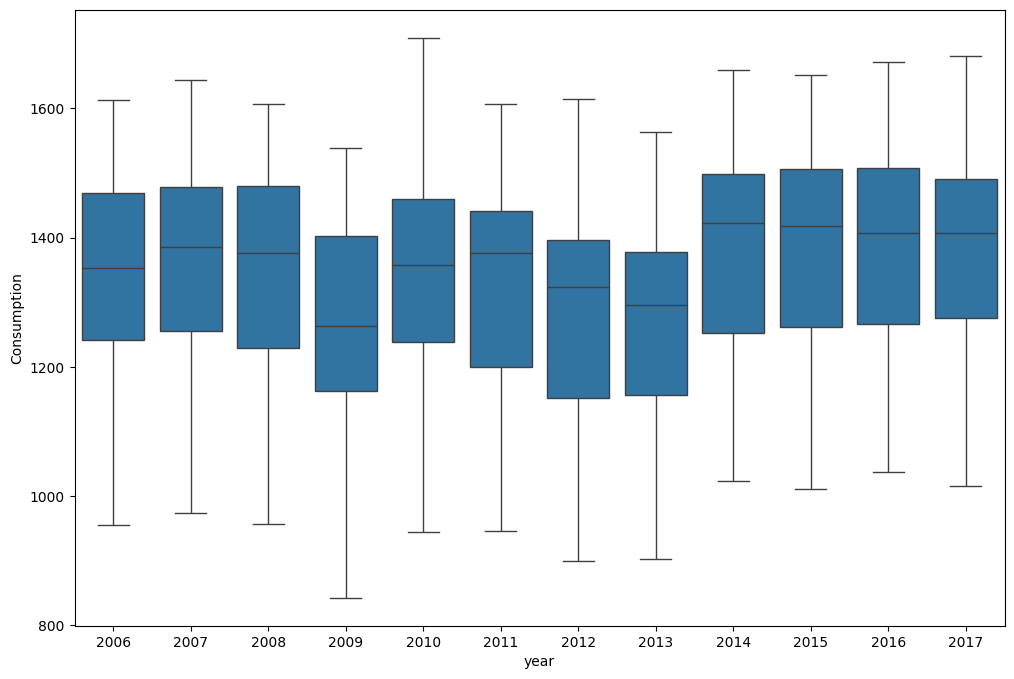

In [10]:
#por ano
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='year', y='Consumption')
plt.show()

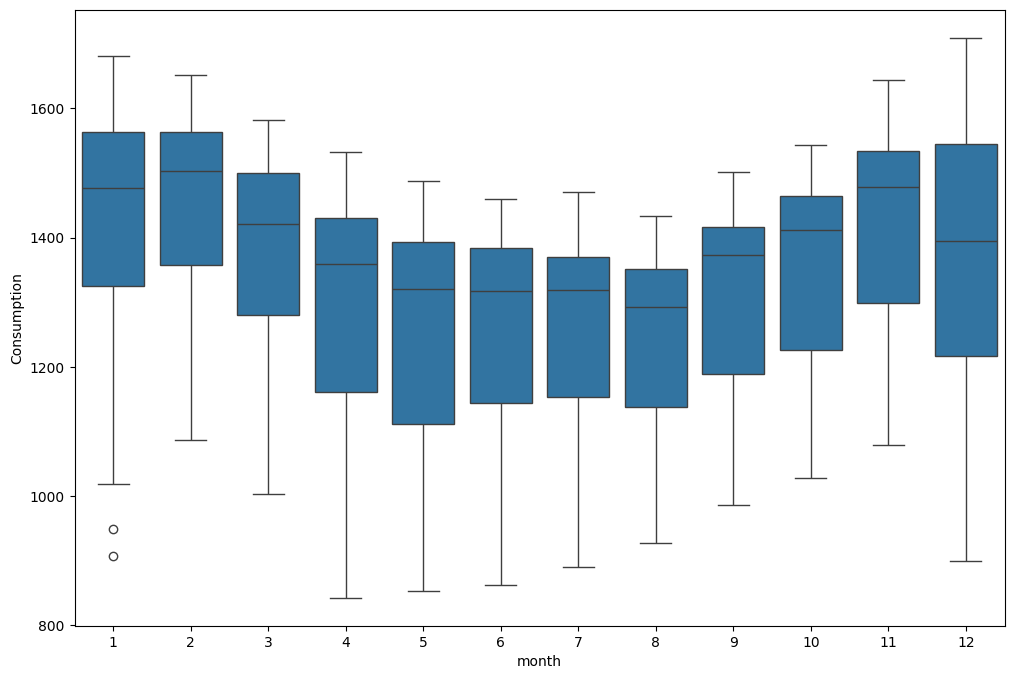

In [11]:
#por mes
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='month', y='Consumption')
plt.show()

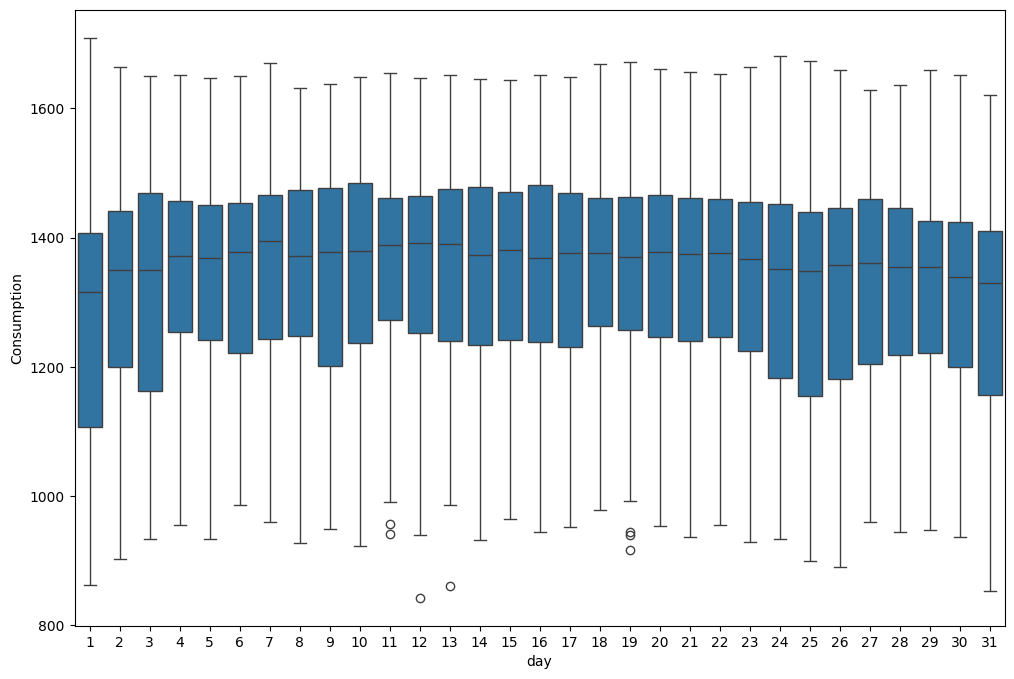

In [12]:
# por dia
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='day', y='Consumption')
plt.show()

## Gerando um novo dataframe (com foco no consumo)

O novo dataframe será usado para modelar a série temporal. Ele contém novas colunas que representam valores de consumo de dias anteriores (chamadas de 'lagged features') e as diferenças entre esses valores. E ideia é fazer a previsão do consumo de um dia d a partir de colunas que representam o consumo em d-1, d-2, etc (e colunas que representam as diferenças de consumo entre d e os dias que o antecedem).

In [13]:
# Faz uma cópia DataFrame apenas com a coluna "Consumption"
df_consumption = df[['Consumption']].copy()
df_consumption.head()

,Consumption
Date,
2006-01-01,1069.184
2006-01-02,1380.521
2006-01-03,1442.533
2006-01-04,1457.217
2006-01-05,1477.131


Observe que as primeiras linhas ficam com várias colunas NaN, visto que não temos dias anteriores para armazenar. Depois precisaremos limpar isso.

In [14]:
# Dicionário para armazenar as novas colunas temporariamente
new_cols = {}

# Cria a coluna Day1, que contém os valores de consumo do dia anterior.
# Cria a coluna DiffDay1, que contém a diferença entre o consumo de Day1 e o consumo do dia imediatamente anterior a 'Day1'.
# O método shift() desloca os dados da série temporal para baixo por um período (neste caso, 1 dia)
new_cols['Day1'] = df_consumption['Consumption'].shift()
new_cols['DiffDay1'] = new_cols['Day1'].diff()

# Cria mais colunas seguindo o mesmo princípio das 2 novas criadas acima
DAYS_BEFORE = 4
for i in range(2, DAYS_BEFORE+1):
    new_cols['Day'+str(i)] = new_cols['Day'+str(i-1)].shift()
    new_cols['DiffDay'+str(i)] = new_cols['Day'+str(i)].diff()

# Transforma o dicionário em DataFrame e junta tudo
df_new_features = pd.DataFrame(new_cols, index=df_consumption.index)
df_consumption = pd.concat([df_consumption, df_new_features], axis=1)

df_consumption.head()

,Consumption,Day1,DiffDay1,Day2,DiffDay2,Day3,DiffDay3,Day4,DiffDay4
Date,,,,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-02,1380.521,1069.184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-03,1442.533,1380.521,311.337,1069.184,NaN,NaN,NaN,NaN,NaN
2006-01-04,1457.217,1442.533,62.012,1380.521,311.337,1069.184,NaN,NaN,NaN
2006-01-05,1477.131,1457.217,14.684,1442.533,62.012,1380.521,311.337,1069.184,NaN


Para simplificar, o código abaixo limpa todas as linhas que ficaram com NaN. Consequentemente, o primeiro dia do data frame passa a ser 2006-01-06 (ao vés de 2006-01-01), para que ele possa ter dados sobre os todos os dias anteriores. Porém, se o modelo não considerar tantos dias, podemos reduzir a quantidade de dados removidos.

In [15]:
# Remove as linhas com NaN
df_consumption = df_consumption.dropna()
df_consumption.head()

,Consumption,Day1,DiffDay1,Day2,DiffDay2,Day3,DiffDay3,Day4,DiffDay4
Date,,,,,,,,,
2006-01-06,1403.427,1477.131,19.914,1457.217,14.684,1442.533,62.012,1380.521,311.337
2006-01-07,1300.287,1403.427,-73.704,1477.131,19.914,1457.217,14.684,1442.533,62.012
2006-01-08,1207.985,1300.287,-103.140,1403.427,-73.704,1477.131,19.914,1457.217,14.684
2006-01-09,1529.323,1207.985,-92.302,1300.287,-103.140,1403.427,-73.704,1477.131,19.914
2006-01-10,1576.911,1529.323,321.338,1207.985,-92.302,1300.287,-103.140,1403.427,-73.704


#### Vamos treinar com os dados de 2016 e testar com os dados de 2017

## Separando treino e teste

In [16]:
X_train = df_consumption[:'2016'].drop(['Consumption'], axis = 1)
y_train = df_consumption.loc[:'2016', 'Consumption']
X_test = df_consumption.loc['2017'].drop(['Consumption'], axis = 1)
y_test = df_consumption.loc['2017', 'Consumption']

## Geracao e Avaliacao dos Modelos

## Imports

Uma novidade

In [17]:
from sklearn.model_selection import TimeSeriesSplit

Outros imports

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Atividade 1:

Execute o código abaixo considerando:

* diferentes complexidades polinomiais;
* diferentes quantidades de dias anteriores (para isso, você deve alterar a preparação do dataset)
* Diferentes opções de parametrização. Observe as interrogações no código (??) sinalizando onde você deve especificar valores. Consulte a documentação das classes para ver as opções.

Ao executar o gradiente, é possível que haja dificuldade para o treinamento convergir. Se isso acontecer, você verá um warning sugerindo para ajustar, por exemplo, a quantidade de interações ou a intesidade da regularização.

Linear: 0.385717 (0.031803)
Ridge: 0.791621 (0.046933)
Lasso: 0.786592 (0.036833)
Elast: 0.749012 (0.034024)


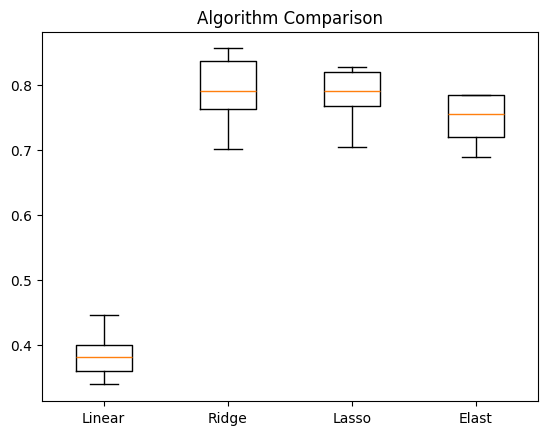

In [19]:
# Cria os pipelines para execução da regressão polinomial
# Aqui não houve preocupação com eficiência (observe que os pipelines repetem passos equivalentes que poderiam ser agrupados). O foco foi na clareza/didática.

deg=3 #TODO defina a complexidade dos modelos polinomiais / execute com mais de uma opção para comparar o impacto

# Linear
poly_ridge_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Ridge
#TODO defina os parâmetros com ??
poly_ridge_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=deg,include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

# Lasso
#TODO defina os parâmetros com ??
poly_lasso_model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, max_iter=5000))
])

# Elastic
poly_elastic_model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
    ('scaler', StandardScaler()),
    ('elast', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000))
])

# Algoritmos
models = []
models.append(('Linear', LinearRegression()))
models.append(('Ridge', poly_ridge_model_pipeline))
models.append(('Lasso', poly_lasso_model_pipeline))
models.append(('Elast', poly_elastic_model_pipeline))

results = []
names = []
for name, model in models: # Validacao Cruzada
  tscv = TimeSeriesSplit(n_splits=10)
  cv_results = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')
  results.append(cv_results)
  names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# Comparacao Visual dos Algoritmos
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()

# Atividade 2.

Gere um comparativo mais completo. Selecione o melhor modelos regularizado e compare-o novamente com o modelo polinomial (sem regularização). Porém, seu comparativo deve incluir diferentes graus de polinômio. Você pode fazer um laço for gerando os cenários automaticamente. Além disso, utilize métricas diferentes além de $r^2$.

Explore as 3 seguintes métricas de Erro (exibindo 3 figuras diferentes):

* **Mean Absolute Error (MAE), ou Erro Médio Absoluto:** dá uma noção real de quanto o seu modelo está errando na mesma unidade da sua variável alvo (y). É bem fácil de interpretar.

* **Root Mean Squared Error (RMSE), ou Raiz do Erro Quadrático Médio:** penaliza erros grandes de forma muito mais severa do que o MAE. Se o seu modelo errar por muito em um determinado período do tempo (um "outlier" temporal), o RMSE vai aumentar muito. É bom quando se quer evitar grandes surpresas.

* **Mean Absolute Percentage Error (MAPE), ou Erro Percentual Absoluto Médio:** mede o erro em porcentagem. É bom para séries temporais onde o valor de y cresce muito ao longo do tempo (ex: vendas de uma empresa que dobram de tamanho). Por exemplo. um erro de 10 unidades importa muito quando o produto vende 100, mas importa pouco quando vende 10.000. O MAPE normaliza isso.

As opções de parâmetro no scikit learn são:

*  scoring='mean_absolute_error'
*  scoring='root_mean_squared_error'
*  scoring='mean_absolute_percentage_error'

Observe que, como estamos falando de erros, quando menor, melhor. Ou seja, a intepretação do boxplot passa a ser insertida em relação ao $r^2$. Se quiser manter a mesma forma de interpretar o boxplot (quanto maior, melhor), usem as métrica equivalente negativas (elas multiplicam o resultado por -1:

*  scoring='neg_mean_absolute_error'
*  scoring='neg_root_mean_squared_error'
*  scoring='neg_mean_absolute_percentage_error'



MAE - Linear deg=1: 103.2574 (3.0803)
MAE - Ridge deg=1: 103.4342 (3.3795)
MAE - Linear deg=2: 52.5268 (5.7264)
MAE - Ridge deg=2: 52.1373 (5.2773)
MAE - Linear deg=3: 48.4725 (8.2847)
MAE - Ridge deg=3: 46.4453 (6.2387)
MAE - Linear deg=4: 43.4370 (19.4345)
MAE - Ridge deg=4: 37.3263 (8.1733)
RMSE - Linear deg=1: 124.5844 (3.1723)
RMSE - Ridge deg=1: 124.4371 (3.0429)
RMSE - Linear deg=2: 79.4153 (6.5215)
RMSE - Ridge deg=2: 78.9796 (5.8617)
RMSE - Linear deg=3: 73.3283 (9.4884)
RMSE - Ridge deg=3: 70.6003 (7.2977)
RMSE - Linear deg=4: 81.5632 (46.0789)
RMSE - Ridge deg=4: 63.5922 (12.8647)
MAPE - Linear deg=1: 0.0813 (0.0035)
MAPE - Ridge deg=1: 0.0813 (0.0033)
MAPE - Linear deg=2: 0.0419 (0.0060)
MAPE - Ridge deg=2: 0.0416 (0.0055)
MAPE - Linear deg=3: 0.0387 (0.0076)
MAPE - Ridge deg=3: 0.0370 (0.0058)
MAPE - Linear deg=4: 0.0346 (0.0149)
MAPE - Ridge deg=4: 0.0298 (0.0067)


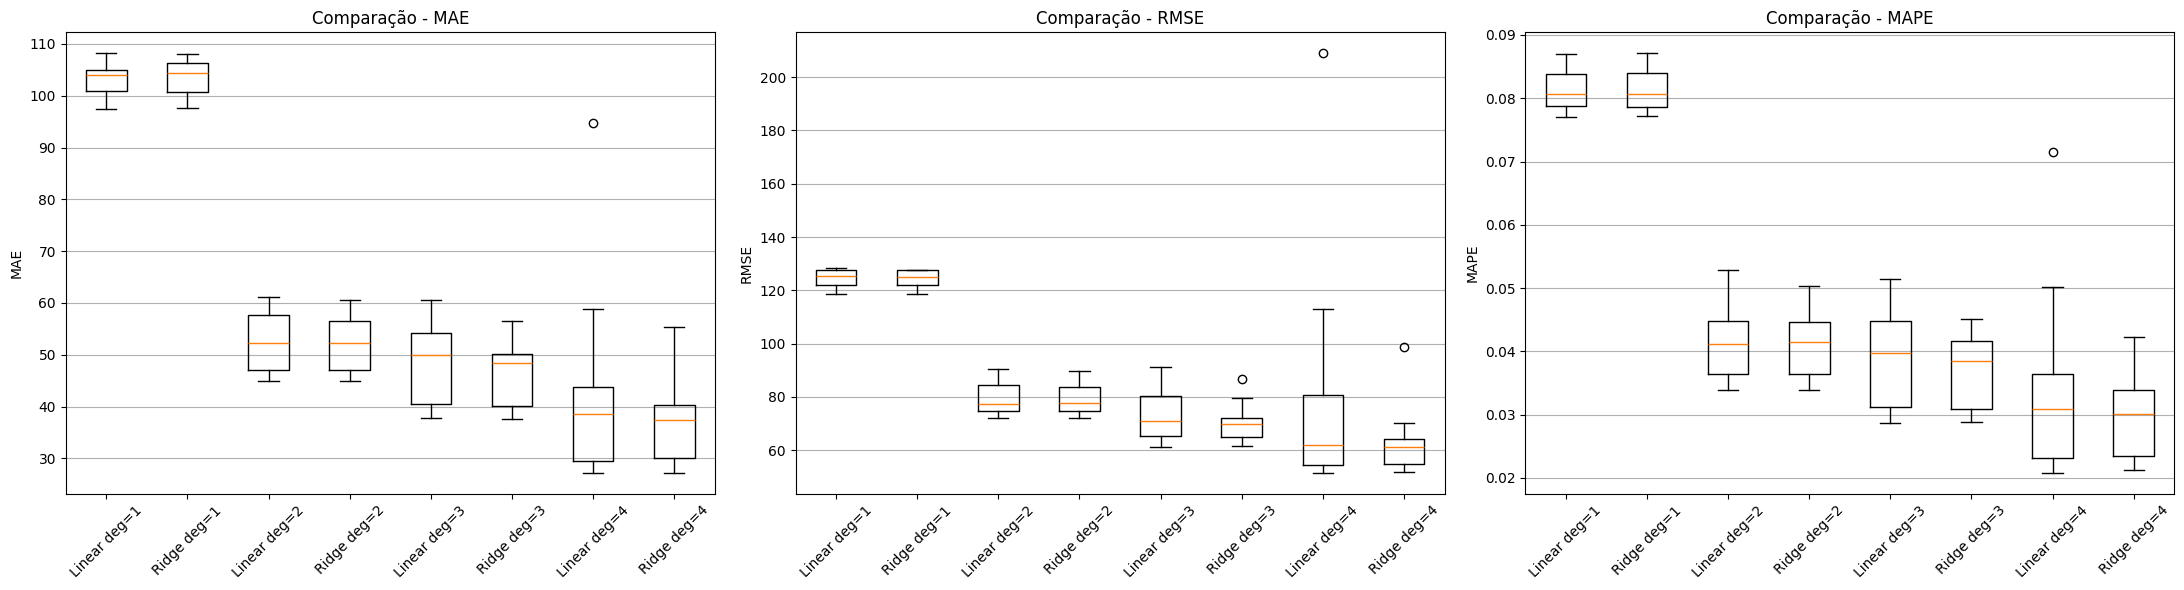

In [20]:
degs = np.arange(1, 5, 1, dtype=int)

metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAPE': 'neg_mean_absolute_percentage_error'
}

tscv = TimeSeriesSplit(n_splits=10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (metric_name, scoring) in zip(axes, metrics.items()):
    results = []
    names = []

    for deg in degs:
        poly_linear_model_pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
        poly_ridge_model_pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0))
        ])

        models = []
        models.append((f'Linear deg={deg}', poly_linear_model_pipeline))
        models.append((f'Ridge deg={deg}', poly_ridge_model_pipeline))

        for name, model in models:
            cv_results = cross_val_score(
                model,
                X_train,
                y_train,
                cv=tscv,
                scoring=scoring
            )

            cv_results = -cv_results
            results.append(cv_results)
            names.append(name)

            print(f'{metric_name} - {name}: {cv_results.mean():.4f} ({cv_results.std():.4f})')

    ax.boxplot(results, labels=names)
    ax.set_title(f'Comparação - {metric_name}')
    ax.set_ylabel(metric_name)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

